##Capstone Project: Retail Sales Analytics


#Project Objective
A retail company wants to analyze its sales performance, customer behavior, product profitability, and monthly sales trends to improve business decisions.


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
sales = pd.read_excel('/content/drive/MyDrive/CapStone_Data/Sales_10000.xlsx')
customers = pd.read_excel('/content/drive/MyDrive/CapStone_Data/Customers.xlsx')
stores = pd.read_excel('/content/drive/MyDrive/CapStone_Data/Stores.xlsx')
products = pd.read_excel('/content/drive/MyDrive/CapStone_Data/Products.xlsx')

In [ ]:
sales.head()

,TransactionID,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,SalesAmount
0,T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80
1,T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61
2,T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25
3,T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48
4,T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08


In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  10000 non-null  object        
 1   OrderDate      10000 non-null  datetime64[ns]
 2   CustomerID     10000 non-null  object        
 3   ProductID      10000 non-null  object        
 4   StoreID        10000 non-null  object        
 5   Quantity       10000 non-null  int64         
 6   UnitPrice      10000 non-null  float64       
 7   Discount       10000 non-null  int64         
 8   PaymentMethod  10000 non-null  object        
 9   SalesAmount    10000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 781.4+ KB


In [ ]:
sales.describe()

,OrderDate,Quantity,UnitPrice,Discount,SalesAmount
count,10000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-06-30 03:41:28.320000,2.997700,2214.665536,7.502000,6156.106643
min,2025-01-01 00:00:00,1.000000,57.270000,0.000000,50.160000
25%,2025-03-31 00:00:00,2.000000,1572.442500,5.000000,2826.217500
50%,2025-06-28 00:00:00,3.000000,2137.970000,5.000000,5472.610000
75%,2025-09-29 00:00:00,4.000000,2906.742500,15.000000,8703.960000
max,2025-12-31 00:00:00,5.000000,4312.250000,15.000000,21518.850000
std,NaN,1.425727,975.168263,5.594026,4212.760239


In [ ]:
sales.set_index("TransactionID", inplace = True)

In [ ]:
sales.head()

,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,SalesAmount
TransactionID,,,,,,,,,
T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80
T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61
T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25
T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48
T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08


#Data Cleaning

Remove duplicates

In [ ]:
sales.drop_duplicates(inplace= True)

Missing Values

In [ ]:
sales.isnull().sum()

,0
OrderDate,0
CustomerID,0
ProductID,0
StoreID,0
Quantity,0
UnitPrice,0
Discount,0
PaymentMethod,0
SalesAmount,0


In [ ]:
sales.fillna(0, inplace= True)

convert text to datetime

In [ ]:
sales['OrderDate'] = pd.to_datetime(sales['OrderDate'])

correct datatypes

In [ ]:
print(sales.dtypes)

OrderDate        datetime64[ns]
CustomerID               object
ProductID                object
StoreID                  object
Quantity                  int64
UnitPrice               float64
Discount                  int64
PaymentMethod            object
SalesAmount             float64
dtype: object


Rename columns

In [ ]:
sales.rename(columns={"SalesAmount":"Revenue"}, inplace= True)

In [ ]:
sales.head()

,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue
TransactionID,,,,,,,,,
T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80
T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61
T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25
T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48
T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08


In [ ]:
#customers.head()

In [ ]:
products.head()

,ProductID,ProductName,Category,Brand,CostPrice
0,P001,Mouse,Electronics,BrandB,1653.81
1,P002,Keyboard,Electronics,BrandA,1043.85
2,P003,Monitor,Electronics,BrandC,961.39
3,P004,Headphones,Electronics,BrandB,1175.83
4,P005,Rice,Groceries,BrandB,1105.07


In [ ]:
stores.head()

,StoreID,StoreName,City,Region
0,S01,Store1,Pune,West
1,S02,Store2,Mumbai,West
2,S03,Store3,Delhi,North
3,S04,Store4,Bengaluru,South
4,S05,Store5,Hyderabad,South


#Data Transformation

Create Total Cost

In [ ]:
sales['TotalCost'] = sales['Quantity'] * sales['UnitPrice']

In [ ]:
sales.head()

,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue,TotalCost
TransactionID,,,,,,,,,,
T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80,4607.56
T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61,2435.38
T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25,5868.25
T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48,160.56
T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08,13979.08


Create Profit

In [ ]:
sales['Profit'] = sales['Revenue'] - sales['TotalCost']

In [ ]:
sales.head()

,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue,TotalCost,Profit
TransactionID,,,,,,,,,,,
T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80,4607.56,-460.76
T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61,2435.38,-121.77
T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25,5868.25,0.00
T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48,160.56,-24.08
T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08,13979.08,0.00


Create Month

In [ ]:
sales['Month'] = sales['OrderDate'].dt.month_name()

In [ ]:
sales.head()

,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue,TotalCost,Profit,Month
TransactionID,,,,,,,,,,,,
T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80,4607.56,-460.76,April
T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61,2435.38,-121.77,September
T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25,5868.25,0.00,October
T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48,160.56,-24.08,January
T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08,13979.08,0.00,July


Create Year

In [ ]:
sales['Year'] = sales['OrderDate'].dt.year

In [ ]:
sales.head()

,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue,TotalCost,Profit,Month,Year
TransactionID,,,,,,,,,,,,,
T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80,4607.56,-460.76,April,2025
T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61,2435.38,-121.77,September,2025
T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25,5868.25,0.00,October,2025
T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48,160.56,-24.08,January,2025
T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08,13979.08,0.00,July,2025


Create Quater

In [ ]:
sales['Quater'] = sales['OrderDate'].dt.quarter

In [ ]:
sales.head()

,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue,TotalCost,Profit,Month,Year,Quater
TransactionID,,,,,,,,,,,,,,
T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80,4607.56,-460.76,April,2025,2
T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61,2435.38,-121.77,September,2025,3
T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25,5868.25,0.00,October,2025,4
T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48,160.56,-24.08,January,2025,1
T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08,13979.08,0.00,July,2025,3


Age Groups

In [ ]:
#customers.head()      # before Adding Agegroup column

In [ ]:
customers['AgeGroup'] = pd.cut(customers['Age'],
                               bins=[18,30,45,60,100],
                               labels=["18-30","31-45","46-60","60+"])

In [ ]:
customers.head()

,CustomerID,CustomerName,Gender,Age,City,State,AgeGroup
0,C0001,Customer 1,Male,61,Mumbai,MH,60+
1,C0002,Customer 2,Female,65,Delhi,MH,60+
2,C0003,Customer 3,Male,51,Bengaluru,DL,46-60
3,C0004,Customer 4,Male,55,Hyderabad,TS,46-60
4,C0005,Customer 5,Female,32,Pune,MH,31-45


#Advanced Aggregation

In [ ]:
sales.head()

,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue,TotalCost,Profit,Month,Year,Quater
TransactionID,,,,,,,,,,,,,,
T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80,4607.56,-460.76,April,2025,2
T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61,2435.38,-121.77,September,2025,3
T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25,5868.25,0.00,October,2025,4
T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48,160.56,-24.08,January,2025,1
T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08,13979.08,0.00,July,2025,3


In [ ]:
products.head()

,ProductID,ProductName,Category,Brand,CostPrice
0,P001,Mouse,Electronics,BrandB,1653.81
1,P002,Keyboard,Electronics,BrandA,1043.85
2,P003,Monitor,Electronics,BrandC,961.39
3,P004,Headphones,Electronics,BrandB,1175.83
4,P005,Rice,Groceries,BrandB,1105.07


Total sales by category

In [ ]:
sales_merged = sales.merge(products, on='ProductID', how='left')

In [ ]:
sales_merged.groupby("Category")["Revenue"].sum()

,Revenue
Category,
Clothing,10962505.52
Electronics,14516981.18
Groceries,17042653.34
Home,19038926.39


Average Profit

In [ ]:
sales_merged.groupby("Category")["Profit"].mean()

,Profit
Category,
Clothing,-346.073393
Electronics,-460.675971
Groceries,-563.373039
Home,-626.275364


Multiple Aggregations

In [ ]:
sales_merged.groupby("Category").agg({"Revenue": ["sum","mean","max"],
                                      "Profit": "sum",
                                      "Quantity": "sum"})

Revenue                             Profit Quantity
                     sum         mean       max         sum      sum
Category                                                            
Clothing     10962505.52  4270.551430  19828.15  -888370.40     7746
Electronics  14516981.18  5661.849134  17784.85 -1181173.19     7642
Groceries    17042653.34  7027.898285  21518.85 -1366179.62     7185
Home         19038926.39  7790.068081  21156.45 -1530616.99     7404

Top 10 customers

In [ ]:
sales.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

,Revenue
CustomerID,
C0190,148831.31
C0717,146559.86
C0521,136739.64
C0555,129453.06
C0897,129041.49
C0013,128109.43
C0819,126939.04
C0765,125096.73
C0357,124488.30


#Merge & Join DataFrames

Merge Sales with Customers

In [ ]:
sales_safe = sales.reset_index()

In [ ]:
sales_customer = pd.merge(sales_safe, customers, on="CustomerID", how="left")

In [ ]:
sales_customer.head()

,TransactionID,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue,...,Profit,Month,Year,Quater,CustomerName,Gender,Age,City,State,AgeGroup
0,T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80,...,-460.76,April,2025,2,Customer 20,Male,59,Bengaluru,MH,46-60
1,T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61,...,-121.77,September,2025,3,Customer 295,Female,47,Pune,TS,46-60
2,T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25,...,0.00,October,2025,4,Customer 501,Male,62,Mumbai,MH,60+
3,T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48,...,-24.08,January,2025,1,Customer 251,Male,52,Bengaluru,TS,46-60
4,T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08,...,0.00,July,2025,3,Customer 16,Male,43,Pune,MH,31-45


Merge Products

In [ ]:
sales_customer_product = pd.merge(sales_customer, products, on="ProductID", how="left")

In [ ]:
sales_customer_product.head()

,TransactionID,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue,...,CustomerName,Gender,Age,City,State,AgeGroup,ProductName,Category,Brand,CostPrice
0,T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80,...,Customer 20,Male,59,Bengaluru,MH,46-60,Jacket,Clothing,BrandC,892.70
1,T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61,...,Customer 295,Female,47,Pune,TS,46-60,Monitor,Electronics,BrandC,961.39
2,T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25,...,Customer 501,Male,62,Mumbai,MH,60+,Jeans,Clothing,BrandA,762.34
3,T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48,...,Customer 251,Male,52,Bengaluru,TS,46-60,T-Shirt,Clothing,BrandC,47.71
4,T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08,...,Customer 16,Male,43,Pune,MH,31-45,Shoes,Clothing,BrandA,1814.30


Merge Stores

In [ ]:
final_df = pd.merge(sales_customer_product, stores, on="StoreID", how="left")

In [ ]:
final_df.head()

,TransactionID,OrderDate,CustomerID,ProductID,StoreID,Quantity,UnitPrice,Discount,PaymentMethod,Revenue,...,City_x,State,AgeGroup,ProductName,Category,Brand,CostPrice,StoreName,City_y,Region
0,T00001,2025-04-15,C0020,P011,S04,4,1151.89,10,UPI,4146.80,...,Bengaluru,MH,46-60,Jacket,Clothing,BrandC,892.70,Store4,Bengaluru,South
1,T00002,2025-09-23,C0295,P003,S02,2,1217.69,5,UPI,2313.61,...,Pune,TS,46-60,Monitor,Electronics,BrandC,961.39,Store2,Mumbai,West
2,T00003,2025-10-23,C0501,P010,S04,5,1173.65,0,Wallet,5868.25,...,Mumbai,MH,60+,Jeans,Clothing,BrandA,762.34,Store4,Bengaluru,South
3,T00004,2025-01-17,C0251,P009,S03,2,80.28,15,Card,136.48,...,Bengaluru,TS,46-60,T-Shirt,Clothing,BrandC,47.71,Store3,Delhi,North
4,T00005,2025-07-06,C0016,P012,S03,4,3494.77,0,Card,13979.08,...,Pune,MH,31-45,Shoes,Clothing,BrandA,1814.30,Store3,Delhi,North


#Time Series Analysis

Set Date Index

In [ ]:
final_df.set_index("OrderDate", inplace= True)

Monthly Sales

In [ ]:
monthly_sales = final_df['Revenue'].resample("M").sum()

/tmp/ipykernel_3845/493907180.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = final_df['Revenue'].resample("M").sum()


In [ ]:
monthly_sales.head()

,Revenue
OrderDate,
2025-01-31,5397530.33
2025-02-28,4739690.74
2025-03-31,5213236.45
2025-04-30,5071434.72
2025-05-31,5242461.61


Monthly Profit

In [ ]:
monthly_profit = final_df['Profit'].resample("M").sum()

/tmp/ipykernel_3845/1840443063.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_profit = final_df['Profit'].resample("M").sum()


In [ ]:
monthly_profit.head()

,Profit
OrderDate,
2025-01-31,-434177.67
2025-02-28,-404664.42
2025-03-31,-422351.58
2025-04-30,-412158.43
2025-05-31,-408275.93


Rolling Average

In [ ]:
rolling_avg = monthly_sales.rolling(3).mean()

In [ ]:
rolling_avg.head()

,Revenue
OrderDate,
2025-01-31,NaN
2025-02-28,NaN
2025-03-31,5.116819e+06
2025-04-30,5.008121e+06
2025-05-31,5.175711e+06


Growth Rate

In [ ]:
growth_rate = monthly_sales.pct_change()*100

In [ ]:
growth_rate.head()

,Revenue
OrderDate,
2025-01-31,NaN
2025-02-28,-12.187789
2025-03-31,9.991068
2025-04-30,-2.720033
2025-05-31,3.372357


Highest Sales Month

In [ ]:
highest_sales_month = monthly_sales.idxmax()

In [ ]:
print(highest_sales_month)

2025-01-31 00:00:00


#Exploratory Data Analysis

In [ ]:
#1.Which city generated the highest revenue?
highest_revenue = final_df.groupby('City_x')["Revenue"].sum().sort_values(ascending=False)

In [ ]:
print(f"Highest Revenue City: {highest_revenue.index[0]} (Revenue: {highest_revenue.iloc[0]:.2f})")

Highest Revenue City: Bengaluru (Revenue: 13219647.00)


In [ ]:
#store location
highest_revenue = final_df.groupby('City_y')["Revenue"].sum().sort_values(ascending=False)
print(f"Highest Revenue City: {highest_revenue.index[0]} (Revenue: {highest_revenue.iloc[0]:.2f})")

Highest Revenue City: Mumbai (Revenue: 12899140.85)


In [ ]:
#2.Which product category sells the most?
top_category = final_df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

In [ ]:
print(f"Top Category: {top_category.index[0]} ({top_category.iloc[0]} item sold)")

Top Category: Clothing (7746 item sold)


In [ ]:
#3.Which payment method is most popular?
top_payment = final_df['PaymentMethod'].value_counts()

In [ ]:
print(f"Top Payment Method: {top_payment.index[0]} ({top_payment.iloc[0]} uses)")

Top Payment Method: UPI (2568 uses)


In [ ]:
#4.Which customer segment spends the most?
top_segment = final_df.groupby("AgeGroup")["Revenue"].sum().sort_values(ascending=False)

/tmp/ipykernel_3845/1194827932.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_segment = final_df.groupby("AgeGroup")["Revenue"].sum().sort_values(ascending=False)


In [ ]:
print(f"Top Segment: {top_segment.index[0]}")

Top Segment: 31-45


In [ ]:
#5.Which store is most profitable?
top_store = final_df.groupby("StoreName")["Profit"].sum().sort_values(ascending=False)

In [ ]:
print(f"Most Profitable Store: {top_store.index[0]}")

Most Profitable Store: Store5


In [ ]:
#6.Which month has maximum sales?
top_month = final_df.groupby("Month")["Revenue"].sum().sort_values(ascending=False)

In [ ]:
print(f"Month with Maximum Sales: {top_month.index[0]}")

Month with Maximum Sales: January


In [ ]:
#7.What is the average basket size?
avg_basket = final_df.groupby("TransactionID")["Quantity"].sum().mean()

In [ ]:
print(f"Average Basket size: {avg_basket:.2f} items per order")

Average Basket size: 3.00 items per order


In [ ]:
#8.Which brand has highest profit?
if "Brand" in final_df.columns:
  top_brand = final_df.groupby("Brand")["Profit"].sum().sort_values(ascending=False)
  print(f"Highest Profit Brand: {top_brand.index[0]}")
else:
  top_product = final_df.groupby("ProductName")["Profit"].sum().sort_values(ascending=False)
  print(f"Highest Profit Product: {top_product.index[0]}")

Highest Profit Brand: BrandC


In [ ]:
#Grab the name
#.index tells Python to look only at the labels on the left side of the list (the names of the cities).

In [ ]:
#The [0]: In programming, counting always starts at zero. So [0] means "grab the very first item in that list."

In [ ]:
#When you ask for top_city.index[0], Python goes to Position 0, looks at the label, and returns the text string "Mumbai".

In [ ]:
#grab the Number
#.iloc stands for "Integer Location". It tells Python to ignore the names entirely and look only at the actual data values on the right side.

In [ ]:
#The [0]: Just like before, it means "go to the 0th row" (the top row).

In [ ]:
#When you ask for top_city.iloc[0], Python goes to Position 0, looks at the data value, and returns the number 450000.

In [ ]:
#when we use this both together
#If we just printed the raw table, it would look messy in a final report. By using string formatting (the f"..." in your code) combined with these two commands, we can write a clean

In [ ]:
final_df.to_excel("Final_Sales_Master.xlsx", index= False)

#Visualizations using Python Library

we used Line Charts for (Sales Trend), Pie Charts for percentages (Payment Distribution), Heatmaps for math relationships (Correlation), and Bar Charts !!

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="whitegrid")

Sales Trend

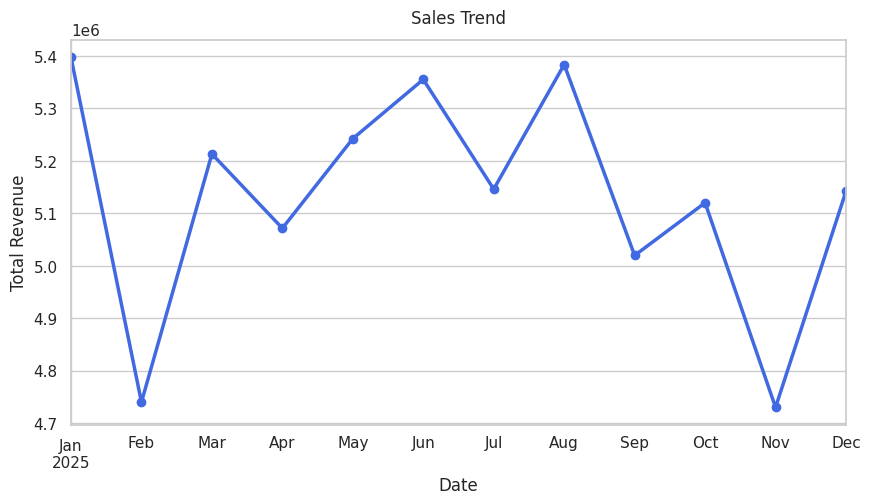

In [ ]:
plt.figure(figsize=(10,5))
if 'OrderDate' in final_df.columns:
  trend_date = final_df.set_index("OrderDate")['Revenue'].resample("ME").sum()
else:
  trend_date = final_df['Revenue'].resample("ME").sum()

trend_date.plot(kind='line', marker='o', color='royalblue', linewidth=2.5)
plt.title("Sales Trend", fontsize= 12, pad=12)
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.show()

Category Revenue

/tmp/ipykernel_3845/3808997478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_rev.index, y=category_rev.values,palette="viridis")


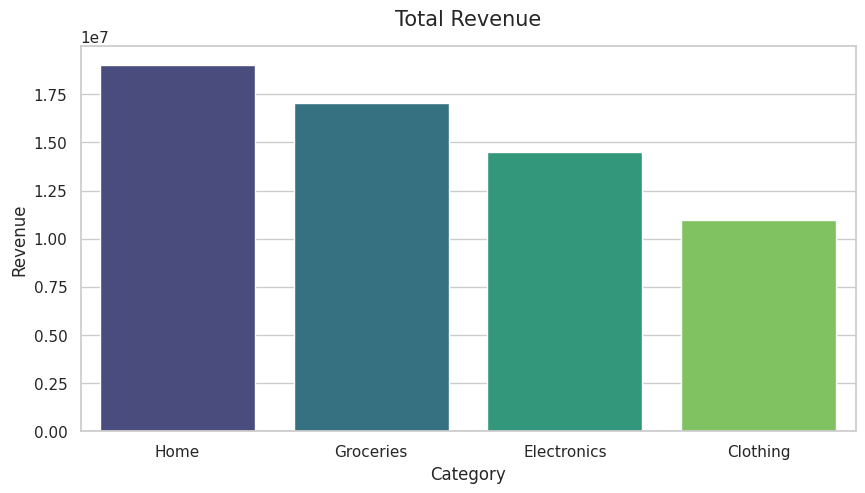

In [ ]:
plt.figure(figsize=(10,5))
category_rev = final_df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
sns.barplot(x=category_rev.index, y=category_rev.values,palette="viridis")
plt.title("Total Revenue", fontsize=15,pad=15)
plt.ylabel("Revenue")
plt.show()

Top Products

/tmp/ipykernel_3845/100187542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values,y=top_products.index,palette="magma")


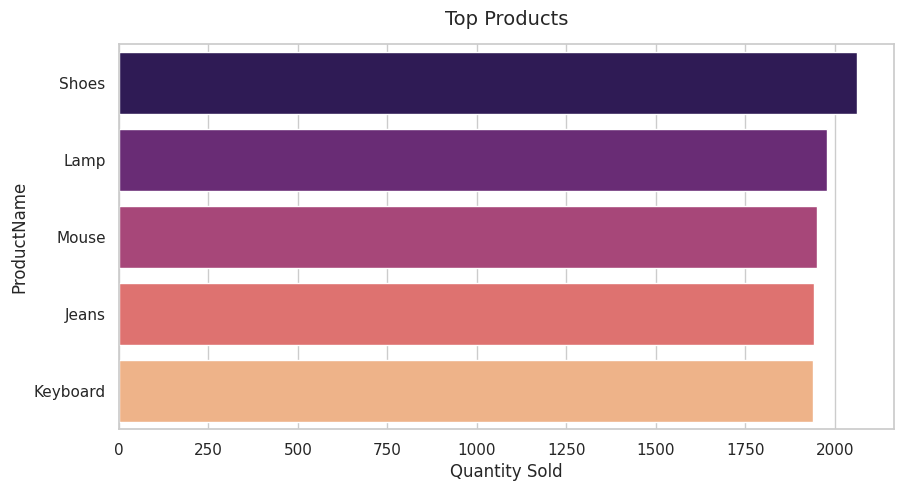

In [ ]:
plt.figure(figsize=(10,5))
top_products = final_df.groupby("ProductName")["Quantity"].sum().nlargest(5)
sns.barplot(x=top_products.values,y=top_products.index,palette="magma")
plt.title("Top Products", fontsize=14, pad=14)
plt.xlabel("Quantity Sold")
plt.ylabel("ProductName")
plt.show()

City-Wise Revenue

/tmp/ipykernel_3845/2796228646.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_rev.index, y= city_rev.values, palette="crest")


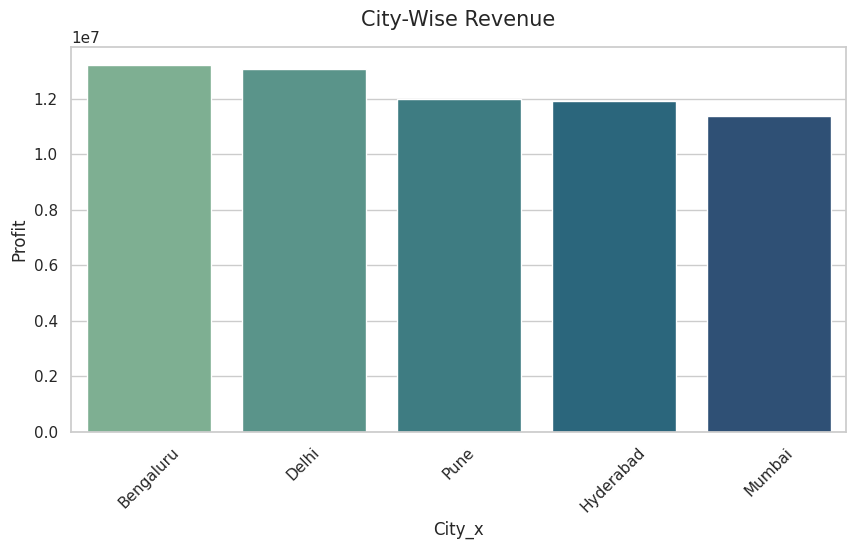

In [ ]:
plt.figure(figsize=(10,5))
city_col = 'City_x' if 'City_x' in final_df.columns else 'City'
city_rev = final_df.groupby(city_col)["Revenue"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=city_rev.index, y= city_rev.values, palette="crest")
plt.title("City-Wise Revenue", fontsize= 15, pad=15)
plt.xticks(rotation=45)
plt.ylabel("Profit")
plt.show()

Profit By Brand

/tmp/ipykernel_3845/4273476078.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_profit.index, y=brand_profit.values, palette="rocket")


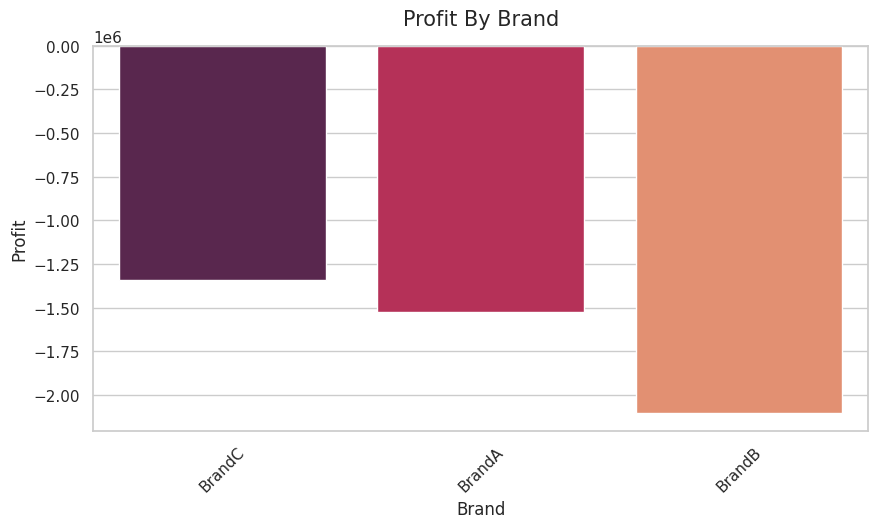

In [ ]:
plt.figure(figsize=(10,5))
brand_col = 'Brand' if 'Brand' in final_df.columns else 'ProductName'
brand_profit = final_df.groupby(brand_col)["Profit"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=brand_profit.index, y=brand_profit.values, palette="rocket")
plt.title("Profit By Brand", fontsize= 15, pad=15)
plt.xticks(rotation=45)
plt.ylabel("Profit")
plt.show()

Monthly Sales

/tmp/ipykernel_3845/1230302707.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_bar.index,y=monthly_bar.values,palette="mako")


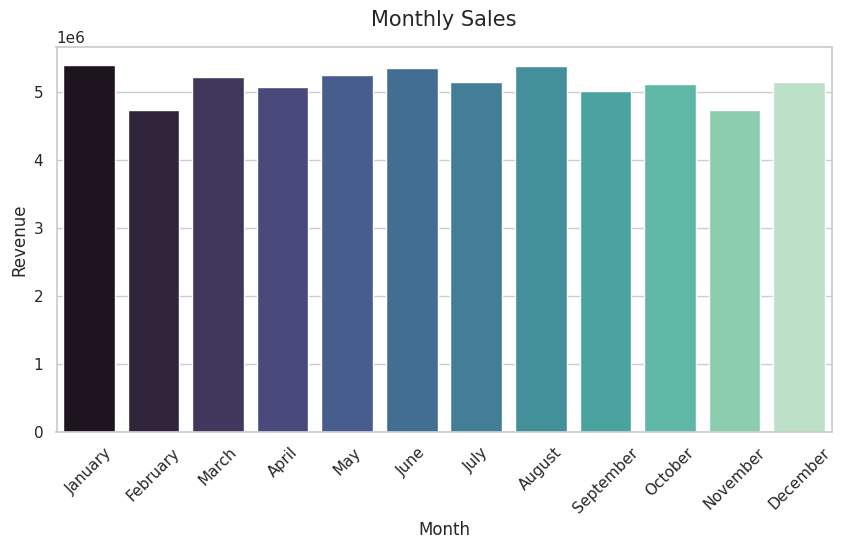

In [ ]:
plt.figure(figsize=(10,5))
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
monthly_bar = final_df.groupby("Month")["Revenue"].sum().reindex(month_order).dropna()
sns.barplot(x=monthly_bar.index,y=monthly_bar.values,palette="mako")
plt.title("Monthly Sales", fontsize=15, pad=15)
plt.xticks(rotation=45)
plt.ylabel("Revenue")
plt.show()

Payment Distribution

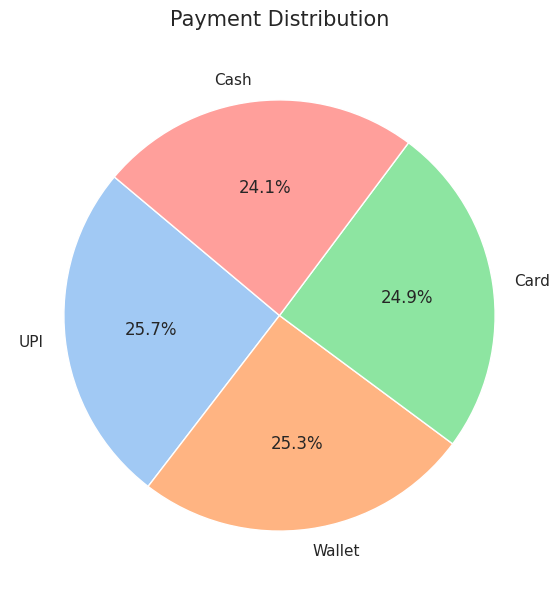

In [ ]:
plt.figure(figsize=(7,7))
payment_counts = final_df["PaymentMethod"].value_counts()
plt.pie(payment_counts, labels=payment_counts.index,autopct='%1.1f%%',
        startangle=140,colors=sns.color_palette("pastel"))
plt.title("Payment Distribution", fontsize= 15, pad=15)
plt.show()

Customer Age Distribution

/tmp/ipykernel_3845/1689519507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="AgeGroup", palette="rainbow",


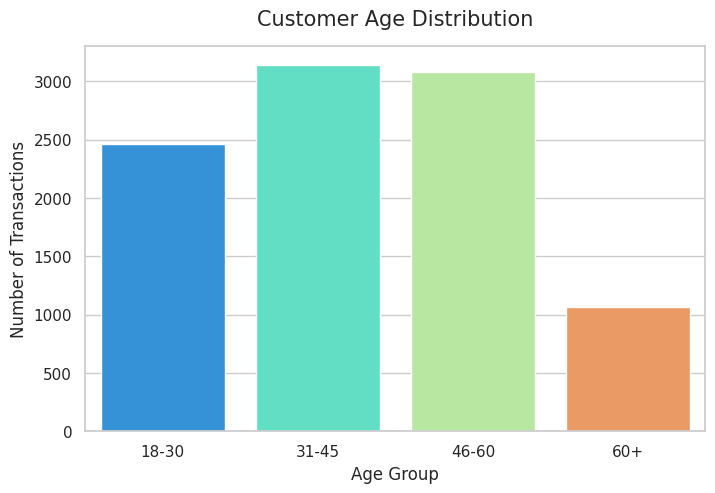

In [ ]:
df_clean = final_df.reset_index(drop=True)
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="AgeGroup", palette="rainbow",
              order=["18-30", "31-45", "46-60", "60+"], legend=False)
plt.title("Customer Age Distribution", fontsize=15, pad=15)
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.show()

Correlation Heatmap

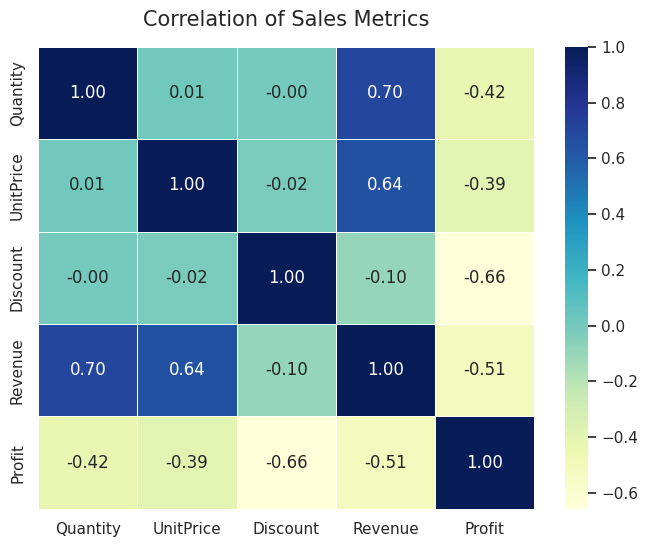

In [ ]:
plt.figure(figsize=(8,6))
numeric_cols = final_df[['Quantity','UnitPrice','Discount','Revenue','Profit']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="YlGnBu", fmt=".2f", linewidths=.5)
plt.title("Correlation of Sales Metrics", fontsize=15, pad=15)
plt.show()

Box Plot

/tmp/ipykernel_3845/10625989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=final_df, x="Category", y="Revenue", palette="crest")


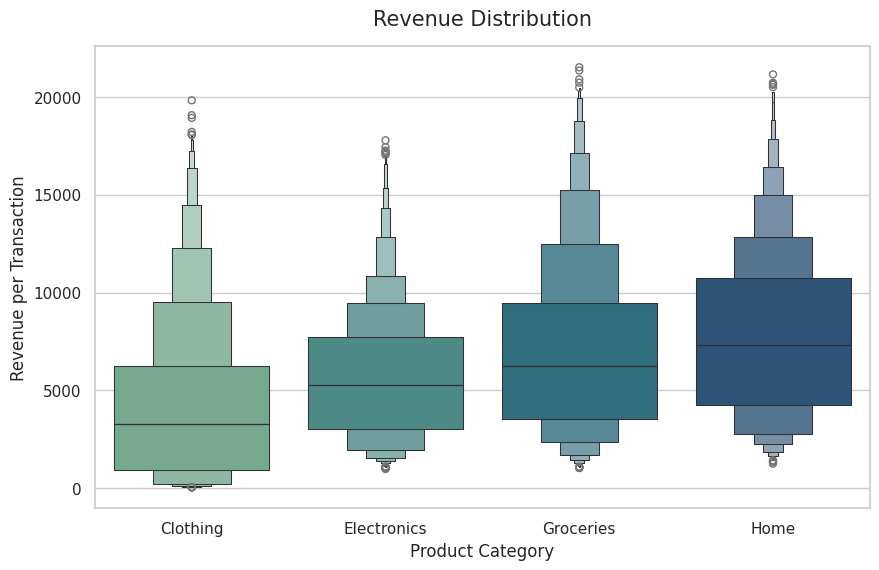

In [ ]:
plt.figure(figsize=(10,6))
sns.boxenplot(data=final_df, x="Category", y="Revenue", palette="crest")
plt.title("Revenue Distribution", fontsize=15, pad=15)
plt.xlabel("Product Category")
plt.ylabel("Revenue per Transaction")
plt.show()